# Medical Image Diagnosis: Pneumonia Detection

## 1. Imports


In [14]:
import tensorflow as tf
from keras import layers, models, applications
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

## 2. Load Data
Using Keras's high-level `image_dataset_from_directory` utility makes loading images straight from folders extremely simple. We will load our `train` and `test` sets directly.


In [2]:
data_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary', # 0 for Normal, 1 for Pneumonia
    shuffle=True
)

print("Loading Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("Loading Testing Data:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False # Don't shuffle test data so we can map predictions back easily
)

class_names = train_dataset.class_names
print("Classes:", class_names)


Loading Training Data:
Found 5216 files belonging to 2 classes.


I0000 00:00:1780038147.984046      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Loading Validation Data:
Found 16 files belonging to 2 classes.
Loading Testing Data:
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [11]:
from collections import Counter
def get_class_counts(dataset):
    labels = []

    for _, y in dataset:
        labels.extend(y.numpy().flatten())

    labels = np.array(labels).astype(int)

    counter = Counter(labels)

    return counter, labels

train_counts, train_labels = get_class_counts(train_dataset)

print("Training Class Distribution:")
for class_index, count in train_counts.items():
    print(f"{class_names[class_index]}: {count}")

Training Class Distribution:
NORMAL: 1341
PNEUMONIA: 3875


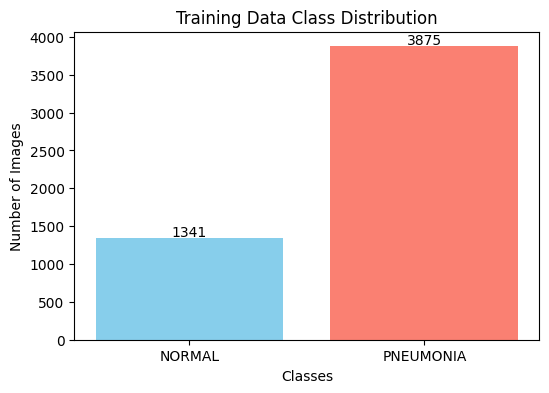

In [12]:
plt.figure(figsize=(6, 4))

classes = [class_names[i] for i in train_counts.keys()]
counts = list(train_counts.values())

bars = plt.bar(classes, counts, color=['skyblue', 'salmon'])

plt.title("Training Data Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        str(height),
        ha='center'
    )

plt.show()

In [15]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


## 3. High-Level Model Builder
Instead of writing complex training loops, TensorFlow allows us to build a model and just call `.fit()`. We'll define a simple function to attach a new classification head to any pre-trained base model.


In [3]:
def build_and_compile_model(base_model, model_name):
    # 1. Freeze the base model so we don't destroy pre-trained features
    base_model.trainable = False
    
    # 2. Build the model sequentially
    model = models.Sequential([
        # Data Augmentation layer to prevent overfitting
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        
        # The Pre-trained base
        base_model,
        
        # Classification Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation='sigmoid') # Binary output (Normal vs Pneumonia)
    ], name=model_name)
    
    # 3. Compile the model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


## 4. Train & Evaluate MobileNetV2
MobileNetV2 expects input pixels to be scaled between [-1, 1]. We handle this using its built-in `preprocess_input` layer.


In [7]:
print("Setting up MobileNetV2...")

# Load MobileNetV2
mobilenet_base = applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# We wrap the base model with its specific preprocessing
mobilenet_input = tf.keras.Sequential([
    layers.InputLayer(input_shape=(224, 224, 3)),
    layers.Lambda(applications.mobilenet_v2.preprocess_input),
    mobilenet_base
])

# Build our final model
mobilenet_model = build_and_compile_model(mobilenet_input, "MobileNetV2")

# Train (Fit) the model using both train and val datasets
print("\nTraining MobileNetV2...")
mobilenet_history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10, # Kept very short for simplicity\n    class_weight=class_weights
)

Setting up MobileNetV2...

Training MobileNetV2...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.8992 - loss: 0.2642 - val_accuracy: 0.7500 - val_loss: 0.4446
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - accuracy: 0.9494 - loss: 0.1459 - val_accuracy: 0.8125 - val_loss: 0.2991
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.9517 - loss: 0.1320 - val_accuracy: 0.9375 - val_loss: 0.2671
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.9582 - loss: 0.1139 - val_accuracy: 0.9375 - val_loss: 0.2478
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.9626 - loss: 0.1060 - val_accuracy: 0.9375 - val_loss: 0.2568
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9641 - loss: 0.1015 - val_accuracy: 0.9375 - val_loss: 0.1469
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9653 - loss: 0.0966 - val_accuracy: 0.9375 - val_loss: 0.1824
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.9680 - loss: 0.0893 - val_accur

## 5. Train & Evaluate ResNet50
ResNet50 requires a different preprocessing scale. We use its built-in preprocessor just like before.


In [8]:
print("Setting up ResNet50...")

# Load ResNet50
resnet_base = applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Wrap with ResNet specific preprocessing
resnet_input = tf.keras.Sequential([
    layers.InputLayer(input_shape=(224, 224, 3)),
    layers.Lambda(applications.resnet50.preprocess_input),
    resnet_base
])

# Build our final model
resnet_model = build_and_compile_model(resnet_input, "ResNet50")

# Train (Fit) the model using both train and val datasets
print("\nTraining ResNet50...")
resnet_history = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)


Setting up ResNet50...

Training ResNet50...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.9145 - loss: 0.2139 - val_accuracy: 0.6250 - val_loss: 0.7098
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9517 - loss: 0.1271 - val_accuracy: 0.6250 - val_loss: 0.7759
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.9626 - loss: 0.0986 - val_accuracy: 0.6250 - val_loss: 0.6876
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 101ms/step - accuracy: 0.9676 - loss: 0.0914 - val_accuracy: 0.8125 - val_loss: 0.3508
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.9686 - loss: 0.0797 - val_accuracy: 0.8750 - val_loss: 0.2380
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.9716 - loss: 0.0746 - val_accuracy: 0.8750 - val_loss: 0.2423
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.9762 - loss: 0.0707 - val_accuracy: 0.8750 - val_loss: 0.1796
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s

## 6. Evaluation and Analysis (Precision, Recall, False Positives/Negatives)
We will extract the true labels from our test set, generate predictions, and evaluate the metrics cleanly.



Analyzing MobileNetV2
              precision    recall  f1-score   support

      NORMAL       0.97      0.61      0.75       234
   PNEUMONIA       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.80      0.82       624
weighted avg       0.87      0.85      0.84       624



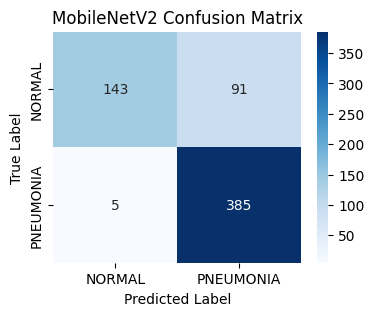

Total False Positives (Predicted Pneumonia, actually Normal): 91
Total False Negatives (Predicted Normal, actually Pneumonia): 5


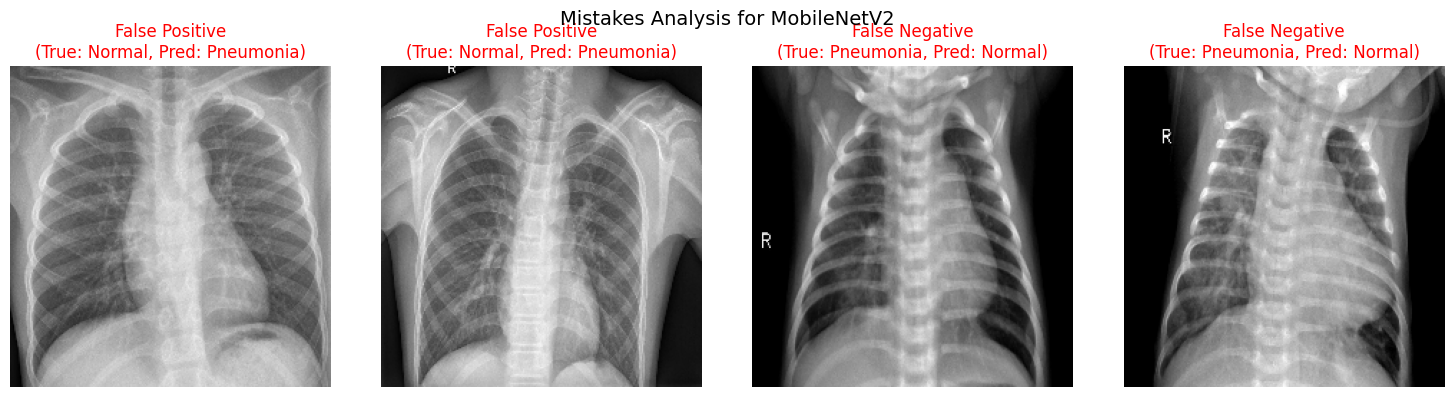


Analyzing ResNet50
              precision    recall  f1-score   support

      NORMAL       0.96      0.57      0.72       234
   PNEUMONIA       0.79      0.98      0.88       390

    accuracy                           0.83       624
   macro avg       0.88      0.78      0.80       624
weighted avg       0.85      0.83      0.82       624



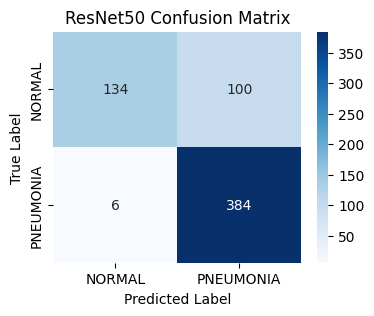

Total False Positives (Predicted Pneumonia, actually Normal): 100
Total False Negatives (Predicted Normal, actually Pneumonia): 6


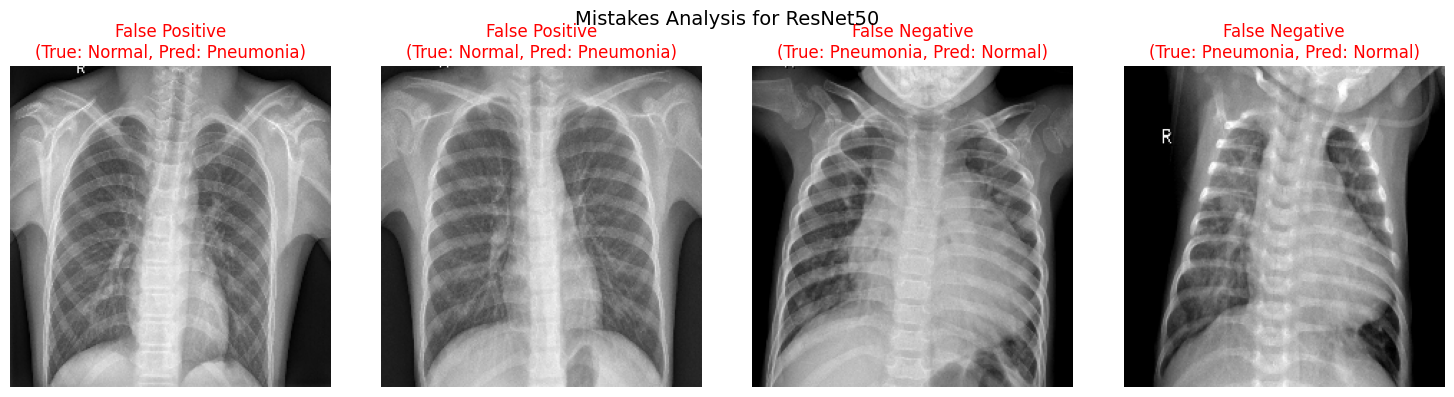

In [9]:
# Extract all test images and true labels into memory for easy analysis
test_images = []
true_labels = []

for images, labels in test_dataset:
    test_images.append(images.numpy())
    true_labels.append(labels.numpy())

test_images = np.concatenate(test_images)
true_labels = np.concatenate(true_labels).flatten()

def evaluate_and_analyze(model):
    print(f"\n{'='*40}\nAnalyzing {model.name}\n{'='*40}")
    
    # Generate predictions
    predicted_probs = model.predict(test_images, verbose=0).flatten()
    predicted_labels = (predicted_probs > 0.5).astype(int)
    
    # 1. Precision, Recall, F1-Score
    print(classification_report(true_labels, predicted_labels, target_names=class_names))
    
    # 2. Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model.name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # 3. Analyze False Positives and False Negatives
    false_positives = np.where((true_labels == 0) & (predicted_labels == 1))[0]
    false_negatives = np.where((true_labels == 1) & (predicted_labels == 0))[0]
    
    print(f"Total False Positives (Predicted Pneumonia, actually Normal): {len(false_positives)}")
    print(f"Total False Negatives (Predicted Normal, actually Pneumonia): {len(false_negatives)}")
    
    # Plot a few mistakes
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    fig.suptitle(f'Mistakes Analysis for {model.name}', fontsize=14)
    
    # Plot up to 2 False Positives
    for i in range(2):
        if i < len(false_positives):
            idx = false_positives[i]
            axes[i].imshow(test_images[idx].astype("uint8"))
            axes[i].set_title("False Positive\n(True: Normal, Pred: Pneumonia)", color='red')
        axes[i].axis('off')
        
    # Plot up to 2 False Negatives
    for i in range(2, 4):
        fn_i = i - 2
        if fn_i < len(false_negatives):
            idx = false_negatives[fn_i]
            axes[i].imshow(test_images[idx].astype("uint8"))
            axes[i].set_title("False Negative\n(True: Pneumonia, Pred: Normal)", color='red')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run Analysis for both models
evaluate_and_analyze(mobilenet_model)
evaluate_and_analyze(resnet_model)
